In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model_ranking.utils import load_h5


# Load Scores

In [2]:
path = "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/predictions/HtoE_DO_a02_model3/train_predictions/predictions/train_predictions.h5"
eval_score_direct = load_h5(path, "F1_eval")
eval_direct_mean = np.mean(eval_score_direct, axis=0)
eval_direct_median = np.median(eval_score_direct, axis=0)

In [3]:
path = "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/09_consis_threshold_HD/patch_selection_best_checkpoint.npz"
HD_consis_scores = np.load(path)["consis_scores"]

In [4]:
path = "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/09_consis_threshold_EI/patch_selection_best_checkpoint.npz"
EI_consis_scores = np.load(path)["consis_scores"]

In [5]:
path = "/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/HD_DOa04/patch_selection_best_checkpoint.npz"
HD_DOa04_consis_scores = np.load(path)["consis_scores"]

# Per Patch Consistency vs F1 Score

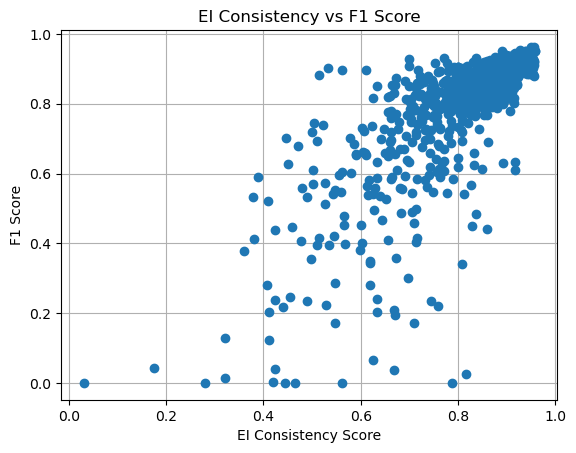

In [8]:
_ = plt.plot(EI_consis_scores, eval_score_direct[:,1], "o", label="EI")
_ = plt.grid()
_ = plt.xlabel("EI Consistency Score")
_ = plt.ylabel("F1 Score")
_ = plt.title("EI Consistency vs F1 Score")

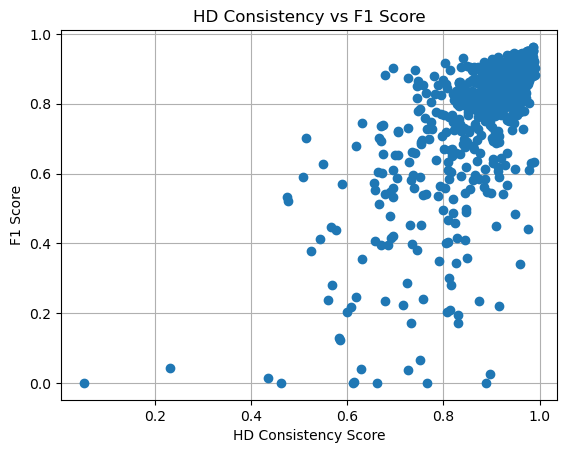

In [9]:
_ = plt.plot(1 - HD_consis_scores, eval_score_direct[:,1], "o", label="EI")
_ = plt.grid()
_ = plt.xlabel("HD Consistency Score")
_ = plt.ylabel("F1 Score")
_ = plt.title("HD Consistency vs F1 Score")

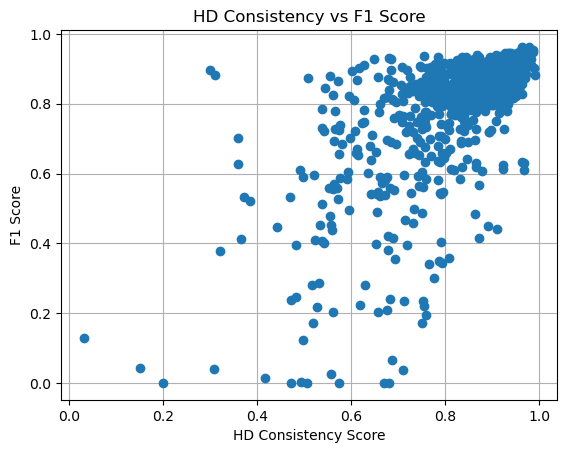

In [10]:
_ = plt.plot(1 - HD_DOa04_consis_scores, eval_score_direct[:,1], "o", label="EI")
_ = plt.grid()
_ = plt.xlabel("HD Consistency Score")
_ = plt.ylabel("F1 Score")
_ = plt.title("HD Consistency vs F1 Score")

# Performance Score cutoff

Number of patches with F1 > 0.8: 731
mean Consistency Score for F1 > 0.8: 0.859


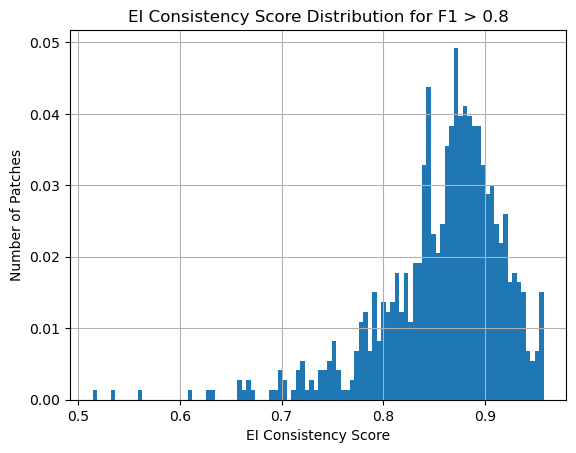

In [11]:
ids = np.where(eval_score_direct[:,1] > 0.8)[0]
print("Number of patches with F1 > 0.8:", len(ids))
consis_scores_selected = EI_consis_scores[ids]
print(f"mean Consistency Score for F1 > 0.8: {np.nanmean(consis_scores_selected):.3f}")
_ = plt.hist(consis_scores_selected, bins=100, weights=np.ones(len(consis_scores_selected)) / len(consis_scores_selected), label="EI")
plt.grid()
_ = plt.xlabel("EI Consistency Score")
_ = plt.ylabel("Number of Patches")
_ = plt.title("EI Consistency Score Distribution for F1 > 0.8")
plt.show()

Number of patches with F1 > 0.8: 731
mean Consistency Score for F1 > 0.8: 0.932


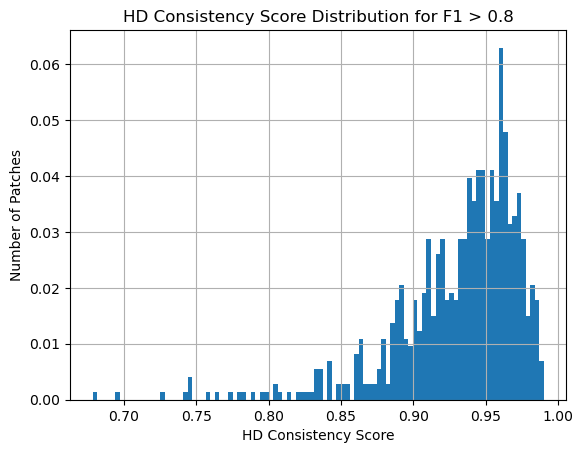

In [13]:
ids = np.where(eval_score_direct[:,1] > 0.8)[0]
print("Number of patches with F1 > 0.8:", len(ids))
consis_scores_selected = 1 - HD_consis_scores[ids]
print(f"mean Consistency Score for F1 > 0.8: {np.nanmean(consis_scores_selected):.3f}")
_ = plt.hist(consis_scores_selected, bins=100, weights=np.ones(len(consis_scores_selected)) / len(consis_scores_selected))
plt.grid()
_ = plt.xlabel("HD Consistency Score")
_ = plt.ylabel("Number of Patches")
_ = plt.title("HD Consistency Score Distribution for F1 > 0.8")
plt.show()

# Filter consistency Score

Number of patches with EI Consistency > 0.8: 681
mean F1 Score for EI Consistency > 0.8: 0.866


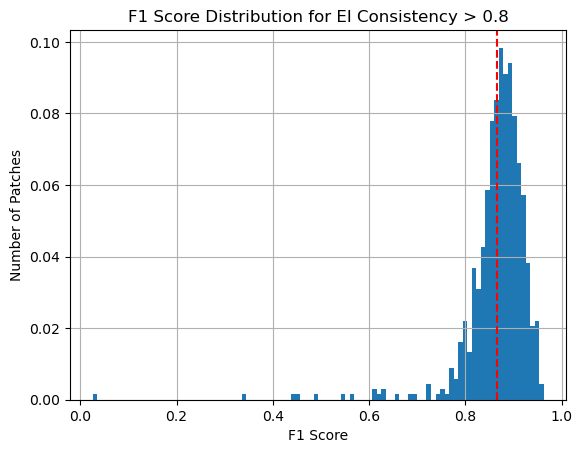

In [15]:
ids = np.where(EI_consis_scores > 0.8)[0]
print("Number of patches with EI Consistency > 0.8:", len(ids))
eval_scores_selected = eval_score_direct[ids, 1]
mean_score = np.nanmean(eval_scores_selected)
print(f"mean F1 Score for EI Consistency > 0.8: {mean_score:.3f}")
_ = plt.hist(eval_scores_selected, bins=100, weights=np.ones(len(eval_scores_selected)) / len(eval_scores_selected))
_ = plt.axvline(mean_score, color="red", linestyle="--", label=f"mean F1 Score: {mean_score:.3f}")
plt.grid()
_ = plt.xlabel("F1 Score")
_ = plt.ylabel("Number of Patches")
_ = plt.title("F1 Score Distribution for EI Consistency > 0.8")
plt.show()

Number of patches with HD Consistency > 0.8: 881
mean F1 Score for HD Consistency > 0.8: 0.835


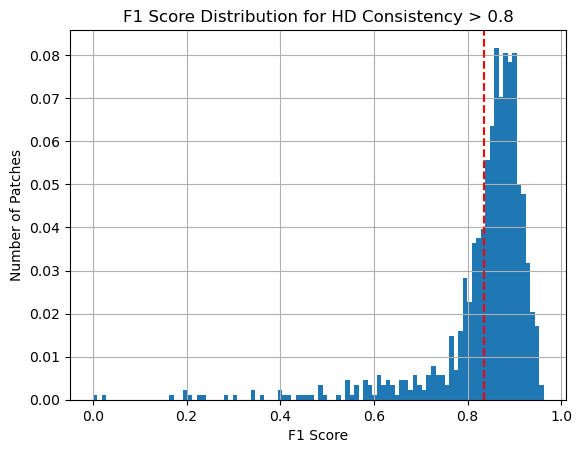

In [17]:
ids = np.where(1 - HD_consis_scores > 0.8)[0]
print("Number of patches with HD Consistency > 0.8:", len(ids))
eval_scores_selected = eval_score_direct[ids, 1]
mean_score = np.nanmean(eval_scores_selected)
print(f"mean F1 Score for HD Consistency > 0.8: {mean_score:.3f}")
_ = plt.hist(eval_scores_selected, bins=100, weights=np.ones(len(eval_scores_selected)) / len(eval_scores_selected))
_ = plt.axvline(mean_score, color="red", linestyle="--", label=f"mean F1 Score: {mean_score:.3f}")
plt.grid()
_ = plt.xlabel("F1 Score")
_ = plt.ylabel("Number of Patches")
_ = plt.title("F1 Score Distribution for HD Consistency > 0.8")
plt.show()

Number of patches with HD DOa04 Consistency > 0.8: 729
mean F1 Score for HD DOa04 Consistency > 0.8: 0.858


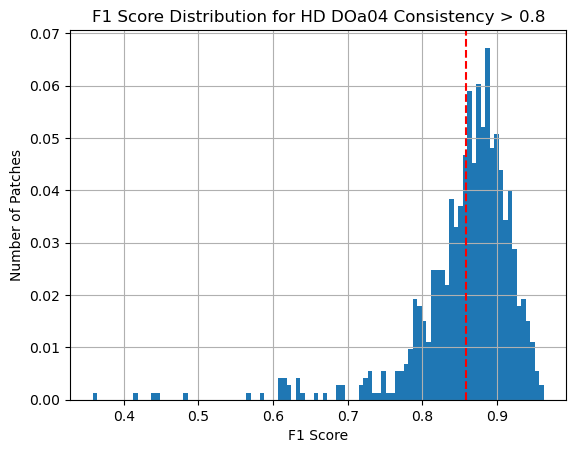

In [18]:
ids = np.where(1 - HD_DOa04_consis_scores > 0.8)[0]
print("Number of patches with HD DOa04 Consistency > 0.8:", len(ids))
eval_scores_selected = eval_score_direct[ids, 1]
mean_score = np.nanmean(eval_scores_selected)
print(f"mean F1 Score for HD DOa04 Consistency > 0.8: {mean_score:.3f}")
_ = plt.hist(eval_scores_selected, bins=100, weights=np.ones(len(eval_scores_selected)) / len(eval_scores_selected))
_ = plt.axvline(mean_score, color="red", linestyle="--", label=f"mean F1 Score: {mean_score:.3f}")
plt.grid()
_ = plt.xlabel("F1 Score")
_ = plt.ylabel("Number of Patches")
_ = plt.title("F1 Score Distribution for HD DOa04 Consistency > 0.8")
plt.show()